# realworld.ipynb

In [10]:
import matplotlib.pyplot as plt
import roadside as rs
import efd_find_cuts as efd
import os
import pandas as pd
import sqlite3
# from dataclasses import dataclass
import numpy as np
import cv2
from icecream import ic
from shapely.geometry import Polygon
from shapely.wkt import loads

# Functions

In [2]:
def get_filtered_contours(tree_contour, tree_mask, min_area=50):
    """ 
    Returns contours of the reconstructed mask that are not present in the original tree mask, filtered by a minimum area threshold (pixel count).
    """
    efd_results = efd.efd_find_cuts(tree_contour, tree_mask, order=80)
    recon_mask = efd_results.reconstructed_mask
    
    additions_mask = cv2.bitwise_and(recon_mask, cv2.bitwise_not(tree_mask))
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(3, 3))
    opened_mask = cv2.morphologyEx(additions_mask, cv2.MORPH_OPEN, kernel, iterations=1)    
    opened_contours, _ = cv2.findContours(opened_mask, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    
    filtered_contours = []
    for cnt in opened_contours:
        # Calculate moments
        M = cv2.moments(cnt)
        if M["m00"] >= min_area:
            filtered_contours.append(cnt)
            
    return filtered_contours

In [3]:
def get_damage_data(df_detections, min_area=50):
    results = []
    damage_id = 1
    for row in df_detections.itertuples():
        tree_contour = rs.wkt2contour(row.tree_wkt).squeeze()
        canvas = np.zeros((row.image_height, row.image_width), dtype="uint8")
        tree_mask = cv2.fillPoly(canvas, [tree_contour], 1)    
        damage_contours = get_filtered_contours(tree_contour, tree_mask, min_area=min_area)
        for damage_contour in damage_contours:
            
            # convert damage_contour to WKT
            polygon = Polygon(np.squeeze(damage_contour))
            damage_wkt = polygon.wkt
            
            mydict = {
                'image_id': row.image_id,
                'detection_id': row.detection_id, 
                'damage_id': damage_id, 
                'damage_wkt': damage_wkt}
            damage_id += 1 
            results.append(mydict)      
    return pd.DataFrame(results)

# df_damage = get_damage_data(df_detections)
# df_damage

# Main

In [4]:
# If it does not already exist, build a database (test.db) containing data from 2 example images.
# The example images will be downloaded to the data_cache directory and SAM3 will
# detect and segment coconut palms.

ic.disable()
if os.path.exists('test.db'):
    pass
else:
    rs.test_build_db()
ic.enable()

In [5]:
# get the data we need from the database
sql = ''' 
SELECT images.image_id, detection_id, image_path, image_width, image_height, tree_wkt
FROM images, detections
WHERE images.image_id=detections.image_id
'''
df_detections = pd.read_sql(sql, sqlite3.connect('test.db'))
df_detections.head()

,image_id,detection_id,image_path,image_width,image_height,tree_wkt
0,1,1,data_cache/example_images/08hs-palms-03-zglw-s...,1366,2048,"POLYGON ((573 829, 576 829, 573 829, 570 825, ..."
1,1,2,data_cache/example_images/08hs-palms-03-zglw-s...,1366,2048,"POLYGON ((1035 1273, 1035 1274, 1034 1275, 103..."
2,2,3,data_cache/example_images/20251129_152106.jpg,1920,1080,"POLYGON ((1153 233, 1152 234, 1151 234, 1150 2..."
3,2,4,data_cache/example_images/20251129_152106.jpg,1920,1080,"POLYGON ((1681 715, 1680 716, 1680 717, 1675 7..."
4,2,5,data_cache/example_images/20251129_152106.jpg,1920,1080,"POLYGON ((1013 829, 1011 831, 1011 832, 1010 8..."


In [6]:
# Add damage table to database
df_damage = get_damage_data(df_detections=df_detections)

# add damage table to database
df_damage.to_sql(
    name="damage",     # Name of the new SQL table
    con=sqlite3.connect("test.db"),
    if_exists="fail",  # Stops execution if the table already exists
    index=False,       # Excludes the DataFrame index from becoming a column
)

# test by reading back from database
df_damage = pd.read_sql('SELECT * FROM damage', sqlite3.connect('test.db'))
df_damage

ValueError: Table 'damage' already exists.

In [7]:
# Get  data for first image
sql = """  
SELECT images.image_id, detections.detection_id, damage.damage_id, image_path, tree_wkt, damage_wkt
FROM images, detections, damage
WHERE 
images.image_id = detections.image_id 
AND images.image_id = damage.image_id
AND images.image_id = 1
"""

df

NameError: name 'df' is not defined

In [ ]:
# display image with damage contours 
img = cv2.imread(df.image_path[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for row in df.itertuples():
    poly = loads(row.damage_wkt)
    ic(poly.area)
    coords = list(poly.exterior.coords)    
    contour = np.array(coords, dtype=np.int32).reshape(-1, 1, 2)
    img = cv2.drawContours(img, [contour], 0, (255,0,0), 2)
    
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title('image with damage contours')
plt.axis("off")  # Removes default graph grid tick measurements
plt.show()


In [ ]:
img.shape

In [ ]:
df_images = pd.read_sql('select * from images', sqlite3.connect('test.db'))
df_detections = pd.read_sql('select * from detections', sqlite3.connect('test.db'))
df_damage = pd.read_sql('select * from damage', sqlite3.connect('test.db'))

# CLEAN CODE

In [8]:
con = sqlite3.connect('test.db')

image_id = 1

sql = f'select image_path from images where image_id={image_id}'
for row in con.execute(sql):
    image_path = row[0]
    ic(image_path)

sql = f'select tree_wkt from detections where image_id = {image_id}'
tree_contours = []
for row in con.execute(sql):
    tree_wkt = row[0]
    poly = loads(tree_wkt)
    coords = list(poly.exterior.coords)    
    contour = np.array(coords, dtype=np.int32).reshape(-1, 1, 2)
    tree_contours.append(contour)
    
con.close()

ic| image_path: 'data_cache/example_images/08hs-palms-03-zglw-superJumbo.webp'


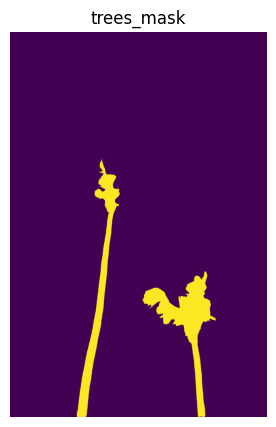

In [15]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Create trees_mask - a binary mask of all trees in an image
canvas = np.zeros(img.shape[:2], np.uint8)
trees_mask = cv2.drawContours(canvas, tree_contours, -1, 255, -1)

plt.figure(figsize=(5, 5))
plt.imshow(trees_mask)
plt.title('trees_mask')
plt.axis("off")  # Removes default graph grid tick measurements
plt.show()

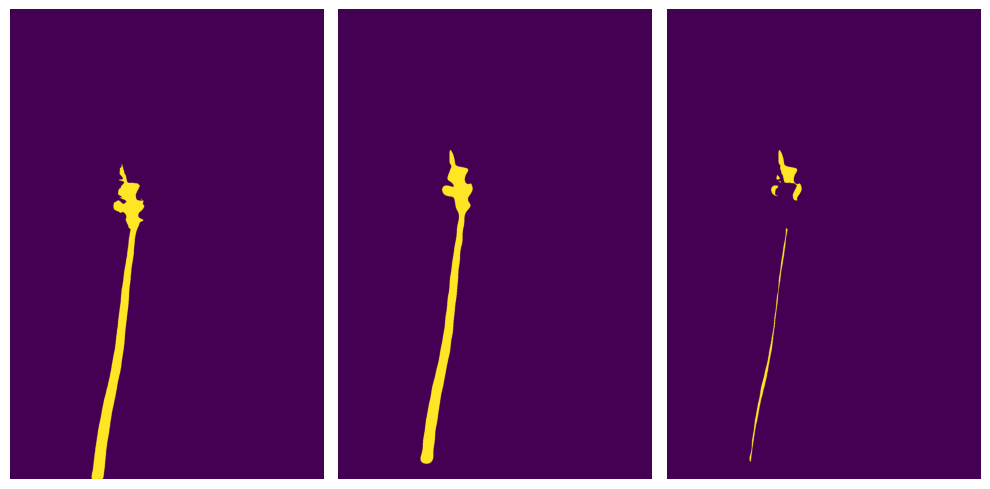

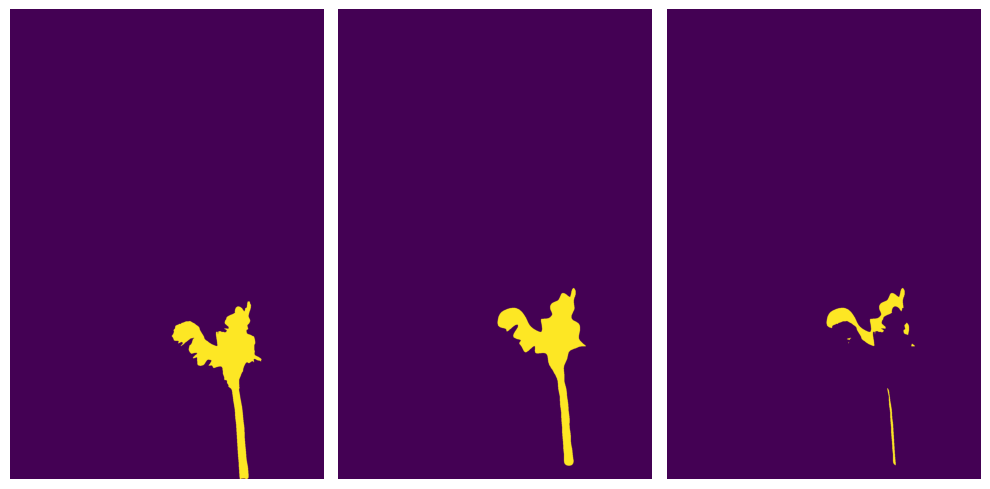

In [28]:
for tree_contour in tree_contours:

    canvas = np.zeros(img.shape[:2], np.uint8)
    tree_mask = cv2.drawContours(canvas, [tree_contour], -1, 255, -1)

    results = efd.efd_find_cuts(tree_contour.squeeze(), tree_mask)
    reconstructed_mask = results.reconstructed_mask
    
    # 3. Additions: Pixels missing in tree_mask, present in reconstructed_mask
    additions_mask = cv2.bitwise_and(reconstructed_mask, cv2.bitwise_not(tree_mask))

    # visulualization
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10,5))
    
    ax1.imshow(tree_mask)
    ax1.axis('off')
    
    ax2.imshow(reconstructed_mask)
    ax2.axis('off')
    
    ax3.imshow(additions_mask)
    ax3.axis('off')
    
    plt.tight_layout()
    plt.show()